In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn

In [4]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


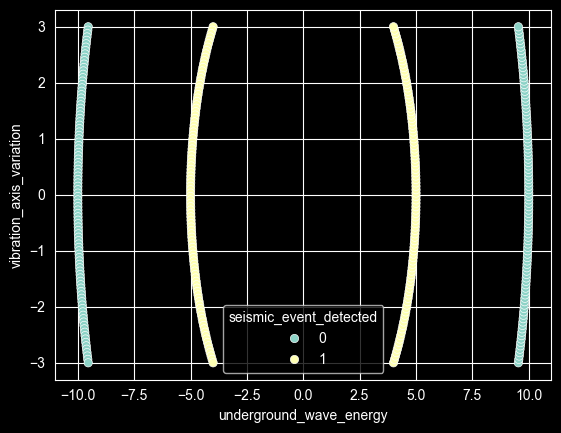

In [6]:
sns.scatterplot(x=df['underground_wave_energy'], y=df['vibration_axis_variation'], hue=df['seismic_event_detected'])
plt.show()

In [7]:
X = df.drop('seismic_event_detected', axis=1).values
y = df['seismic_event_detected'].values

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [10]:
class BasicLinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1 = nn.Linear(in_features=2, out_features=4)
        self.linear_2 = nn.Linear(in_features=4, out_features=1)

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return self.linear_2(self.linear_1(x))


In [11]:
model = BasicLinearClassifier()
print(model)

BasicLinearClassifier(
  (linear_1): Linear(in_features=2, out_features=4, bias=True)
  (linear_2): Linear(in_features=4, out_features=1, bias=True)
)


In [12]:
torch.manual_seed(42)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [13]:
# Calculate accuracy. we can use torchmetrics for measuring accuracy, but let's do it manually now
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item() # torch.eq() calculates when two tensors are equal
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [14]:
epochs = 500

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_train, y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test, test_pred)

    if epoch % 5 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.81509, Accuracy: 51.25% | Test loss: 0.82646, Test acc: 45.00%
Epoch: 5 | Loss: 0.69570, Accuracy: 51.25% | Test loss: 0.69758, Test acc: 38.75%
Epoch: 10 | Loss: 0.70572, Accuracy: 51.88% | Test loss: 0.69909, Test acc: 57.50%
Epoch: 15 | Loss: 0.70180, Accuracy: 54.37% | Test loss: 0.70721, Test acc: 52.50%
Epoch: 20 | Loss: 0.69211, Accuracy: 52.50% | Test loss: 0.72322, Test acc: 38.75%
Epoch: 25 | Loss: 0.69477, Accuracy: 59.69% | Test loss: 0.73284, Test acc: 48.75%
Epoch: 30 | Loss: 0.69318, Accuracy: 59.69% | Test loss: 0.71839, Test acc: 48.75%
Epoch: 35 | Loss: 0.69143, Accuracy: 52.50% | Test loss: 0.70330, Test acc: 40.00%
Epoch: 40 | Loss: 0.69228, Accuracy: 52.19% | Test loss: 0.70062, Test acc: 40.00%
Epoch: 45 | Loss: 0.69156, Accuracy: 53.44% | Test loss: 0.70657, Test acc: 38.75%
Epoch: 50 | Loss: 0.69141, Accuracy: 51.88% | Test loss: 0.71394, Test acc: 40.00%
Epoch: 55 | Loss: 0.69153, Accuracy: 53.12% | Test loss: 0.71452, Test acc: 40.00%
Epoch:

In [15]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.linear_1.weight.detach().numpy()       # shape (5,2)
    b1 = model.linear_1.bias.detach().numpy()         # shape (5,)
    W2 = model.linear_2.weight.detach().numpy()       # shape (1,5)
    b2 = model.linear_2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

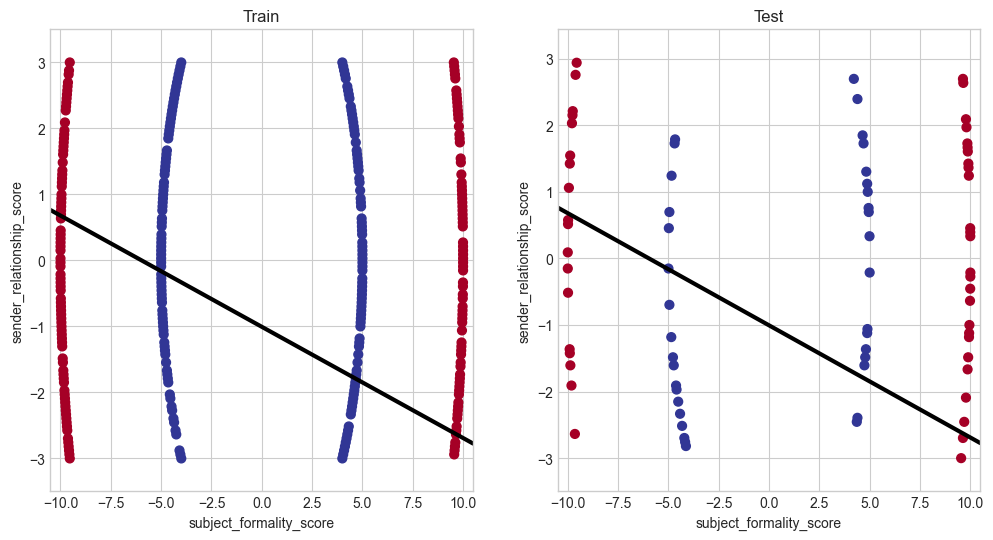

In [16]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model, X_test, y_test)

plt.show()

In [17]:
class NonLinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1 = nn.Linear(in_features=2, out_features=4)
        self.linear_2 = nn.Linear(in_features=4, out_features=1)

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return self.linear_2(torch.relu(self.linear_1(x)))

In [18]:
torch.manual_seed(42)

model_relu = NonLinearClassifier()

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_relu.parameters(), lr=0.01)

epochs = 500

for epoch in range(epochs):
    model_relu.train()

    y_logits = model_relu(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_train, y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_relu.eval()
    with torch.inference_mode():
        test_logits = model_relu(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test, test_pred)

    if epoch % 5 == 0:  # Her 50'de bir yeterli artık
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.06318, Acc: 51.25% | Test Loss: 1.22245, Test Acc: 45.00%
Epoch: 5 | Loss: 0.91282, Acc: 51.25% | Test Loss: 1.03733, Test Acc: 45.00%
Epoch: 10 | Loss: 0.81442, Acc: 65.62% | Test Loss: 0.90937, Test Acc: 57.50%
Epoch: 15 | Loss: 0.75303, Acc: 51.25% | Test Loss: 0.82236, Test Acc: 45.00%
Epoch: 20 | Loss: 0.71494, Acc: 51.25% | Test Loss: 0.76547, Test Acc: 45.00%
Epoch: 25 | Loss: 0.68899, Acc: 51.25% | Test Loss: 0.72784, Test Acc: 45.00%
Epoch: 30 | Loss: 0.66874, Acc: 51.25% | Test Loss: 0.70156, Test Acc: 45.00%
Epoch: 35 | Loss: 0.65252, Acc: 51.25% | Test Loss: 0.68304, Test Acc: 45.00%
Epoch: 40 | Loss: 0.63865, Acc: 51.25% | Test Loss: 0.66756, Test Acc: 45.00%
Epoch: 45 | Loss: 0.62568, Acc: 51.25% | Test Loss: 0.65428, Test Acc: 45.00%
Epoch: 50 | Loss: 0.61257, Acc: 53.75% | Test Loss: 0.63843, Test Acc: 45.00%
Epoch: 55 | Loss: 0.59431, Acc: 56.56% | Test Loss: 0.61733, Test Acc: 45.00%
Epoch: 60 | Loss: 0.56637, Acc: 75.00% | Test Loss: 0.58023, Test 

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_decision_boundary(model, X, y, title="Karar Sınırı"):
    """
    Herhangi bir PyTorch binary classification modeli için
    karar sınırı çizer. Linear veya non-linear fark etmez.

    Args:
        model : eğitilmiş nn.Module (sigmoid olmadan logit döndürmeli)
        X     : torch.Tensor, shape (N, 2) — sadece 2 feature desteklenir
        y     : torch.Tensor, shape (N, 1) veya (N,)
        title : grafik başlığı
    """
    model.eval()

    # --- 1. Uzayı kapsayan grid oluştur ---
    # Verinin min/max değerlerine biraz boşluk bırak
    x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
    y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5

    # 500x500 noktalık ızgara — daha yüksek = daha keskin sınır
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    # --- 2. Grid noktalarını modele sok ---
    # Her (x, y) çiftini bir satır yap: shape (500*500, 2)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

    with torch.inference_mode():
        # Logit → sigmoid → 0/1 tahmini
        logits = model(grid_tensor)              # (250000, 1)
        probs  = torch.sigmoid(logits)           # olasılığa çevir
        preds  = (probs > 0.5).float()           # eşik uygula
        zz     = preds.numpy().reshape(xx.shape) # grid şekline geri al

    # --- 3. Renk haritasını çiz ---
    plt.contourf(xx, yy, zz, alpha=0.4, cmap=plt.cm.RdYlBu)

    # --- 4. Gerçek veri noktaları ---
    plt.scatter(
        X[:, 0], X[:, 1],
        c=y.squeeze().numpy(),
        cmap=plt.cm.RdYlBu,
        edgecolors='k',
        s=40
    )

    plt.title(title)
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

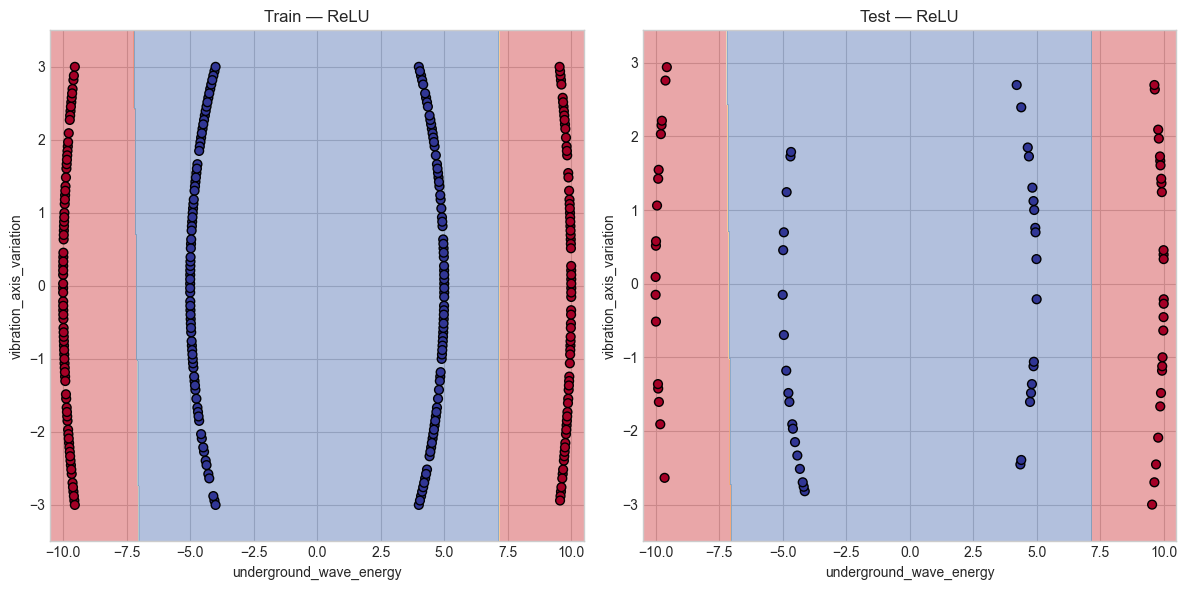

In [21]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_decision_boundary(model_relu, X_train, y_train, title="Train — ReLU")

plt.subplot(1, 2, 2)
plot_decision_boundary(model_relu, X_test, y_test, title="Test — ReLU")

plt.tight_layout()
plt.show()